# 08g — ESMFold Structural Validation (updated)

Direct continuation of PEARL Pipeline 4 (08f). ESMFold is used as an independent structural/conformational plausibility check, not as a peptide–EGFR affinity estimator. The bound-reference comparison asks whether an isolated ESMFold model resembles the receptor-bound peptide conformation. A low RMSD may support conformational preorganisation, but does not demonstrate binding affinity, binding stability, or correct receptor recognition.

Short-peptide predictions can be poorly constrained. pLDDT and RMSD are therefore reported as comparative, descriptive QC signals rather than interpreted with rigid thresholds developed for folded protein domains.


## 1. Configuration

Set the input paths in this cell before execution. For a complete bound-reference validation, provide the complex/reference PDB, its peptide-chain identifier, and the biologically defined protected positions. Protected positions must come from the upstream ProteinMPNN/interface definition and must not be invented in this notebook.


In [1]:
from pathlib import Path
import ast
import hashlib
import importlib.metadata
import json
import shutil
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ---------------- USER CONFIGURATION ----------------
PREDICTION_MODE = "external"  # "local" or "external"

# Notebook 08f, used as the authoritative source of candidate IDs/sequences.

NB08F = Path(
    "/Users/robertobruzzese/Downloads/"
    "08f_ProteinMPNN_Endpoint_Energy_Comparison_TEST=FALSE.ipynb"
)
# External ESMFold PDB directory. Required in external mode; files must be named <candidate_id>.pdb.

EXTERNAL_PDB_DIR = Path(
    "/Users/robertobruzzese/Desktop/venv/outputs/"
    "esmfold_external"
) # e.g. Path("outputs/esmfold_pdbs")

# Bound complex/reference. Leave REFERENCE_PDB=None for an explicitly labelled pLDDT-only run.
REFERENCE_PDB = Path(
    "/Users/robertobruzzese/Desktop/venv/outputs/"
    "clear_local_peptide_dataset_04c/"
    "foldx_buildmodel/"
    "F0010_native_complex.pdb"
)  # e.g. Path("path/to/EGFR_bound_peptide_complex.pdb")
REFERENCE_PEPTIDE_CHAIN = "D"  # e.g. "P"

# ESMFold normally emits a single chain named A.
PREDICTED_PEPTIDE_CHAIN = "A"

# Biological sequence positions, 1-based. Populate only from an upstream protected/fixed-position definition.
PROTECTED_POSITIONS_1BASED = [2, 4, 6, 7, 8, 10]  # e.g. [3, 6, 7]

# This implementation supports equal-length, no-indel variants mapped by biological sequence index.
REFERENCE_MAPPING_MODE = "sequence_index"

OUTPUT_ROOT = Path("outputs/pipeline_4_ai_08g_esmfold_structural_validation")
TABLE_DIR = OUTPUT_ROOT / "tables"
FIGURE_DIR = OUTPUT_ROOT / "figures"
PDB_DIR = OUTPUT_ROOT / "predicted_pdb"
ALIGNED_DIR = OUTPUT_ROOT / "aligned_pdb"

for directory in (TABLE_DIR, FIGURE_DIR, PDB_DIR, ALIGNED_DIR):
    directory.mkdir(parents=True, exist_ok=True)

if REFERENCE_MAPPING_MODE != "sequence_index":
    raise NotImplementedError("This notebook currently implements sequence-index mapping only.")
if REFERENCE_PDB is not None:
    REFERENCE_PDB = Path(REFERENCE_PDB)
    if not REFERENCE_PDB.exists():
        raise FileNotFoundError(f"Reference PDB not found: {REFERENCE_PDB}")
    if not REFERENCE_PEPTIDE_CHAIN:
        raise ValueError("Set REFERENCE_PEPTIDE_CHAIN when REFERENCE_PDB is supplied.")
if len(PROTECTED_POSITIONS_1BASED) != len(set(PROTECTED_POSITIONS_1BASED)):
    raise ValueError("PROTECTED_POSITIONS_1BASED contains duplicates.")
if any((not isinstance(p, int)) or p < 1 for p in PROTECTED_POSITIONS_1BASED):
    raise ValueError("Protected positions must be positive 1-based integers.")

run_config = {
    "prediction_mode": PREDICTION_MODE,
    "nb08f": str(NB08F),
    "external_pdb_dir": str(EXTERNAL_PDB_DIR) if EXTERNAL_PDB_DIR is not None else None,
    "reference_pdb": str(REFERENCE_PDB) if REFERENCE_PDB is not None else None,
    "reference_peptide_chain": REFERENCE_PEPTIDE_CHAIN,
    "predicted_peptide_chain": PREDICTED_PEPTIDE_CHAIN,
    "protected_positions_1based": PROTECTED_POSITIONS_1BASED,
    "reference_mapping_mode": REFERENCE_MAPPING_MODE,
}
(OUTPUT_ROOT / "08g_run_config.json").write_text(json.dumps(run_config, indent=2))
display(pd.Series(run_config, name="value").to_frame())


,value
prediction_mode,external
nb08f,/Users/robertobruzzese/Downloads/08f_ProteinMP...
external_pdb_dir,/Users/robertobruzzese/Desktop/venv/outputs/es...
reference_pdb,/Users/robertobruzzese/Desktop/venv/outputs/cl...
reference_peptide_chain,D
predicted_peptide_chain,A
protected_positions_1based,"[2, 4, 6, 7, 8, 10]"
reference_mapping_mode,sequence_index


## 2. Candidate traceability from 08f

Candidate identifiers and sequences are extracted from the 08f source rather than retyped. The parser accepts literal assignments and reports a clear error if 08f changes to a non-literal construction.


In [2]:
if not NB08F.exists():
    raise FileNotFoundError(f"08f notebook not found: {NB08F}")

nb08f = json.loads(NB08F.read_text())
source08f = "\n".join(
    "".join(cell.get("source", []))
    for cell in nb08f["cells"]
    if cell.get("cell_type") == "code"
)

def extract_literal_assignment(source, name):
    tree = ast.parse(source)
    for node in tree.body:
        if isinstance(node, (ast.Assign, ast.AnnAssign)):
            targets = node.targets if isinstance(node, ast.Assign) else [node.target]
            if any(isinstance(target, ast.Name) and target.id == name for target in targets):
                value_node = node.value
                try:
                    return ast.literal_eval(value_node)
                except Exception as exc:
                    raise ValueError(
                        f"{name} exists in 08f but is not a literal assignment; "
                        "export it from 08f as JSON/CSV for robust transfer."
                    ) from exc
    raise KeyError(f"Could not extract {name} from 08f")

TARGET_CANDIDATES = extract_literal_assignment(source08f, "TARGET_CANDIDATES")
CANDIDATE_SEQUENCES = extract_literal_assignment(source08f, "CANDIDATE_SEQUENCES")

if not TARGET_CANDIDATES:
    raise ValueError("TARGET_CANDIDATES is empty.")
if set(TARGET_CANDIDATES) != set(CANDIDATE_SEQUENCES):
    raise ValueError("08f candidate IDs and sequence dictionary keys differ.")
if any(not isinstance(seq, str) or not seq for seq in CANDIDATE_SEQUENCES.values()):
    raise ValueError("Every candidate must have a non-empty sequence.")

candidate_df = pd.DataFrame([
    {
        "candidate_id": cid,
        "sequence": CANDIDATE_SEQUENCES[cid],
        "sequence_length": len(CANDIDATE_SEQUENCES[cid]),
    }
    for cid in TARGET_CANDIDATES
])
candidate_df.to_csv(TABLE_DIR / "08g_candidates_from_08f.csv", index=False)
display(candidate_df)


,candidate_id,sequence,sequence_length
0,MPNN_NEW_01,TGPRNQYRDLP,11
1,MPNN_NEW_05,IGPRHQYRDLP,11


## 3. Upstream input traceability

Expected 08e topology/trajectory paths are recorded for provenance only. Their absence does not prevent 08g from running because the ESMFold/reference comparison does not use the MD trajectory.


In [3]:
MD_ROOT = Path("outputs/pipeline_4_ai_08e_top_mpnn_md/production_1ns")
traceability_rows = []

for cid in TARGET_CANDIDATES:
    trajectory_dir = MD_ROOT / cid / "trajectory"
    topology_candidates = [
        trajectory_dir / f"{cid}_protein_MDA_topology.pdb",
        trajectory_dir / f"{cid}_protein_topology.pdb",
    ]
    trajectory_candidates = [
        trajectory_dir / f"{cid}_production_protein.dcd",
        trajectory_dir / f"{cid}_production_full.dcd",
    ]
    topology = next((p for p in topology_candidates if p.exists()), None)
    trajectory = next((p for p in trajectory_candidates if p.exists()), None)
    traceability_rows.append({
        "candidate_id": cid,
        "sequence": CANDIDATE_SEQUENCES[cid],
        "topology_pdb": str(topology) if topology else None,
        "topology_present": topology is not None,
        "trajectory_dcd": str(trajectory) if trajectory else None,
        "trajectory_present": trajectory is not None,
    })

input_df = pd.DataFrame(traceability_rows)
input_df.to_csv(TABLE_DIR / "08g_input_traceability.csv", index=False)
display(input_df)


,candidate_id,sequence,topology_pdb,topology_present,trajectory_dcd,trajectory_present
0,MPNN_NEW_01,TGPRNQYRDLP,outputs/pipeline_4_ai_08e_top_mpnn_md/producti...,True,outputs/pipeline_4_ai_08e_top_mpnn_md/producti...,True
1,MPNN_NEW_05,IGPRHQYRDLP,outputs/pipeline_4_ai_08e_top_mpnn_md/producti...,True,outputs/pipeline_4_ai_08e_top_mpnn_md/producti...,True


## 4. Software and prediction mode

External mode imports real ESMFold PDB files and never fabricates predictions. Local mode loads ESMFold once and reuses the model for every candidate.


In [4]:
ESM_AVAILABLE = False
ESM_IMPORT_ERROR = None
esm = None
torch = None

try:
    import esm
    import torch
    ESM_AVAILABLE = True
except Exception as exc:
    ESM_IMPORT_ERROR = repr(exc)

if PREDICTION_MODE not in {"local", "external"}:
    raise ValueError("PREDICTION_MODE must be 'local' or 'external'.")
if PREDICTION_MODE == "local" and not ESM_AVAILABLE:
    raise ImportError(
        "Local prediction requested, but ESMFold is unavailable. "
        f"Original error: {ESM_IMPORT_ERROR}"
    )
if PREDICTION_MODE == "external":
    if EXTERNAL_PDB_DIR is None:
        raise ValueError("Set EXTERNAL_PDB_DIR in external mode.")
    EXTERNAL_PDB_DIR = Path(EXTERNAL_PDB_DIR)
    if not EXTERNAL_PDB_DIR.exists():
        raise FileNotFoundError(f"External PDB directory not found: {EXTERNAL_PDB_DIR}")

def package_version(name):
    try:
        return importlib.metadata.version(name)
    except importlib.metadata.PackageNotFoundError:
        return None

software_versions = {
    "python": sys.version,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": package_version("matplotlib"),
    "biopython": package_version("biopython"),
    "fair-esm": package_version("fair-esm"),
    "torch": getattr(torch, "__version__", None),
    "esm_available": ESM_AVAILABLE,
    "esm_import_error": ESM_IMPORT_ERROR,
}
(OUTPUT_ROOT / "08g_software_versions.json").write_text(
    json.dumps(software_versions, indent=2)
)
display(pd.Series(software_versions, name="version").to_frame())


,version
python,"3.11.15 | packaged by conda-forge | (main, Jun..."
numpy,2.4.6
pandas,3.0.5
matplotlib,3.11.1
biopython,1.88
fair-esm,2.0.0
torch,2.13.0
esm_available,True
esm_import_error,None


## 5. PDB parsing and sequence controls

Only the configured peptide chain and first structural model are used. PDB sequence, residue count, Cα availability, and pLDDT range are checked explicitly.


In [5]:
from Bio.PDB import PDBParser, PDBIO, Superimposer
from Bio.PDB.Polypeptide import is_aa, protein_letters_3to1

parser = PDBParser(QUIET=True)
BACKBONE_ATOMS = ("N", "CA", "C", "O")

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

def get_chain(structure, chain_id):
    model = next(structure.get_models())
    available = [chain.id for chain in model]
    if chain_id not in available:
        raise ValueError(f"Chain {chain_id!r} not found; available chains: {available}")
    return model[chain_id]

def get_standard_residues(chain):
    return [residue for residue in chain if is_aa(residue, standard=True)]

def residue_to_one_letter(residue):
    return protein_letters_3to1.get(residue.resname.upper(), "X")

def load_peptide(pdb_path, chain_id, structure_id):
    structure = parser.get_structure(structure_id, str(pdb_path))
    chain = get_chain(structure, chain_id)
    residues = get_standard_residues(chain)
    if not residues:
        raise ValueError(f"No standard amino-acid residues in chain {chain_id!r}: {pdb_path}")
    sequence = "".join(residue_to_one_letter(residue) for residue in residues)
    return structure, residues, sequence

def select_corresponding_atoms(reference_residues, predicted_residues, positions_1based, atom_names=("CA",)):
    reference_atoms, predicted_atoms, used_positions, skipped_positions = [], [], [], []
    for position in positions_1based:
        if position > len(reference_residues) or position > len(predicted_residues):
            skipped_positions.append(position)
            continue
        ref_residue = reference_residues[position - 1]
        pred_residue = predicted_residues[position - 1]
        if not all(name in ref_residue and name in pred_residue for name in atom_names):
            skipped_positions.append(position)
            continue
        for atom_name in atom_names:
            reference_atoms.append(ref_residue[atom_name])
            predicted_atoms.append(pred_residue[atom_name])
        used_positions.append(position)
    return reference_atoms, predicted_atoms, used_positions, skipped_positions

def fit_atoms(reference_atoms, predicted_atoms):
    if len(reference_atoms) != len(predicted_atoms):
        raise ValueError("Reference and predicted atom counts differ.")
    if len(reference_atoms) < 3:
        return None
    superimposer = Superimposer()
    superimposer.set_atoms(reference_atoms, predicted_atoms)
    return superimposer

def rmsd_without_refitting(reference_atoms, predicted_atoms):
    if len(reference_atoms) != len(predicted_atoms) or not reference_atoms:
        return np.nan
    differences = np.asarray([
        ref.coord - pred.coord for ref, pred in zip(reference_atoms, predicted_atoms)
    ])
    return float(np.sqrt(np.mean(np.sum(differences ** 2, axis=1))))


## 6. ESMFold predictions and per-residue pLDDT

pLDDT is read from the Cα B-factor field used by ESMFold PDB output. Both summary and per-residue values are exported.


In [6]:
model = None
device = None
if PREDICTION_MODE == "local":
    model = esm.pretrained.esmfold_v1().eval()
    device = "cuda" if torch.cuda.is_available() else "cpu"
    if device == "cuda":
        model = model.cuda()

def local_predict(sequence, output_path, loaded_model):
    with torch.no_grad():
        pdb_text = loaded_model.infer_pdb(sequence)
    Path(output_path).write_text(pdb_text)

summary_rows = []
per_residue_rows = []

for cid in TARGET_CANDIDATES:
    expected_sequence = CANDIDATE_SEQUENCES[cid]
    output_pdb = PDB_DIR / f"{cid}.pdb"
    source_pdb = None

    if PREDICTION_MODE == "external":
        source_pdb = EXTERNAL_PDB_DIR / f"{cid}.pdb"
        if not source_pdb.exists():
            raise FileNotFoundError(source_pdb)
        shutil.copy2(source_pdb, output_pdb)
    else:
        local_predict(expected_sequence, output_pdb, model)

    structure, residues, observed_sequence = load_peptide(
        output_pdb, PREDICTED_PEPTIDE_CHAIN, cid
    )
    sequence_matches = observed_sequence == expected_sequence
    if not sequence_matches:
        raise ValueError(
            f"{cid}: PDB sequence {observed_sequence!r} does not match "
            f"expected sequence {expected_sequence!r}."
        )

    ca_records = [(position, residue, residue["CA"]) for position, residue in enumerate(residues, 1) if "CA" in residue]
    plddt = np.asarray([atom.bfactor for _, _, atom in ca_records], dtype=float)
    plddt_valid = bool(
        len(plddt) == len(expected_sequence)
        and np.isfinite(plddt).all()
        and ((plddt >= 0) & (plddt <= 100)).all()
    )
    if not plddt_valid:
        raise ValueError(f"{cid}: invalid/incomplete C-alpha pLDDT values.")

    for position, residue, atom in ca_records:
        per_residue_rows.append({
            "candidate_id": cid,
            "sequence": expected_sequence,
            "sequence_position": position,
            "residue": residue_to_one_letter(residue),
            "pdb_resseq": residue.id[1],
            "pdb_icode": residue.id[2].strip() or None,
            "pLDDT": float(atom.bfactor),
            "is_protected": position in PROTECTED_POSITIONS_1BASED,
        })

    all_atoms = list(structure.get_atoms())
    summary_rows.append({
        "candidate_id": cid,
        "sequence": expected_sequence,
        "pdb_path": str(output_pdb),
        "source_pdb": str(source_pdb) if source_pdb is not None else None,
        "pdb_sha256": sha256_file(output_pdb),
        "predicted_chain": PREDICTED_PEPTIDE_CHAIN,
        "n_atoms": len(all_atoms),
        "n_residues_expected": len(expected_sequence),
        "n_residues_observed": len(residues),
        "n_CA": len(ca_records),
        "observed_sequence": observed_sequence,
        "sequence_matches_expected": sequence_matches,
        "mean_pLDDT": float(np.mean(plddt)),
        "median_pLDDT": float(np.median(plddt)),
        "min_pLDDT": float(np.min(plddt)),
        "max_pLDDT": float(np.max(plddt)),
        "fraction_pLDDT_lt_50": float(np.mean(plddt < 50)),
        "fraction_pLDDT_ge_70": float(np.mean(plddt >= 70)),
        "pLDDT_valid": plddt_valid,
    })

result_df = pd.DataFrame(summary_rows)
per_residue_df = pd.DataFrame(per_residue_rows)
per_residue_df.to_csv(TABLE_DIR / "08g_ESMFold_per_residue_metrics.csv", index=False)
display(result_df)
display(per_residue_df)


,candidate_id,sequence,pdb_path,source_pdb,pdb_sha256,predicted_chain,n_atoms,n_residues_expected,n_residues_observed,n_CA,observed_sequence,sequence_matches_expected,mean_pLDDT,median_pLDDT,min_pLDDT,max_pLDDT,fraction_pLDDT_lt_50,fraction_pLDDT_ge_70,pLDDT_valid
0,MPNN_NEW_01,TGPRNQYRDLP,outputs/pipeline_4_ai_08g_esmfold_structural_v...,/Users/robertobruzzese/Desktop/venv/outputs/es...,86dda100ca2cdaf08e42b8c7c3317a99a6e27969fba0ae...,A,92,11,11,11,TGPRNQYRDLP,True,72.559091,72.86,68.59,75.83,0.0,0.727273,True
1,MPNN_NEW_05,IGPRHQYRDLP,outputs/pipeline_4_ai_08g_esmfold_structural_v...,/Users/robertobruzzese/Desktop/venv/outputs/es...,2059cc088595e4b5252db8072b7dc1d7ee1f2865a7963c...,A,95,11,11,11,IGPRHQYRDLP,True,67.273636,66.39,62.53,74.31,0.0,0.181818,True


,candidate_id,sequence,sequence_position,residue,pdb_resseq,pdb_icode,pLDDT,is_protected
0,MPNN_NEW_01,TGPRNQYRDLP,1,T,1,None,73.35,False
1,MPNN_NEW_01,TGPRNQYRDLP,2,G,2,None,69.85,True
2,MPNN_NEW_01,TGPRNQYRDLP,3,P,3,None,69.45,False
3,MPNN_NEW_01,TGPRNQYRDLP,4,R,4,None,70.21,True
4,MPNN_NEW_01,TGPRNQYRDLP,5,N,5,None,68.59,False
5,MPNN_NEW_01,TGPRNQYRDLP,6,Q,6,None,74.32,True
6,MPNN_NEW_01,TGPRNQYRDLP,7,Y,7,None,75.32,True
7,MPNN_NEW_01,TGPRNQYRDLP,8,R,8,None,72.58,True
8,MPNN_NEW_01,TGPRNQYRDLP,9,D,9,None,72.86,False
9,MPNN_NEW_01,TGPRNQYRDLP,10,L,10,None,75.83,True


## 7. Bound/reference structural comparison

For equal-length no-indel variants, residue position *i* in each candidate maps to residue position *i* in the bound peptide. The code refuses to compare unequal lengths because silently truncating or pairing atoms by PDB order would be scientifically unsafe.

Reported metrics:

- **global Cα RMSD**: optimal fit on all mapped peptide Cα atoms;
- **global backbone RMSD after Cα fit**: N/CA/C/O deviation in the same globally aligned frame;
- **protected RMSD after global fit**: protected-site deviation in the whole-peptide frame;
- **protected local-fit RMSD**: internal protected-motif geometry after a separate protected-site fit (requires at least three protected Cα atoms).


In [7]:
reference_available = REFERENCE_PDB is not None
comparison_rows = []
deviation_rows = []

if reference_available:
    reference_structure, reference_residues, reference_sequence = load_peptide(
        REFERENCE_PDB, REFERENCE_PEPTIDE_CHAIN, "bound_reference"
    )
    candidate_lengths = {len(seq) for seq in CANDIDATE_SEQUENCES.values()}
    if len(candidate_lengths) != 1:
        raise ValueError("Candidate lengths differ; an explicit sequence alignment/mapping is required.")
    expected_length = next(iter(candidate_lengths))
    if len(reference_residues) != expected_length:
        raise ValueError(
            f"Reference peptide has {len(reference_residues)} residues; candidates have {expected_length}. "
            "Provide an explicit residue mapping instead of positional mapping."
        )
    if any(position > expected_length for position in PROTECTED_POSITIONS_1BASED):
        raise ValueError("A protected position exceeds the peptide length.")
    all_positions = list(range(1, expected_length + 1))
else:
    reference_structure = reference_residues = reference_sequence = None
    warnings.warn(
        "REFERENCE_PDB is None: pLDDT analysis will run, but bound-reference validation is NOT performed."
    )

for row in result_df.itertuples(index=False):
    cid = row.candidate_id
    if not reference_available:
        comparison_rows.append({
            "candidate_id": cid,
            "reference_comparison_status": "not_run_reference_not_configured",
            "reference_pdb": None,
            "reference_chain": None,
            "reference_sequence": None,
            "global_CA_RMSD_A": np.nan,
            "global_backbone_RMSD_after_CA_fit_A": np.nan,
            "protected_CA_RMSD_after_global_fit_A": np.nan,
            "protected_CA_RMSD_local_fit_A": np.nan,
            "n_mapped_positions": 0,
            "reference_mapping_coverage": np.nan,
            "aligned_pdb_path": None,
            "protected_comparison_status": "not_run_reference_not_configured",
        })
        continue

    predicted_structure, predicted_residues, predicted_sequence = load_peptide(
        row.pdb_path, PREDICTED_PEPTIDE_CHAIN, f"{cid}_prediction"
    )
    ref_ca, pred_ca, mapped_positions, skipped_positions = select_corresponding_atoms(
        reference_residues, predicted_residues, all_positions, atom_names=("CA",)
    )
    if skipped_positions:
        raise ValueError(f"{cid}: missing C-alpha atoms at positions {skipped_positions}.")
    global_fit = fit_atoms(ref_ca, pred_ca)
    if global_fit is None:
        raise ValueError(f"{cid}: fewer than three mapped C-alpha atoms.")
    global_fit.apply(list(predicted_structure.get_atoms()))
    global_ca_rmsd = float(global_fit.rms)

    ref_bb, pred_bb, backbone_positions, skipped_backbone = select_corresponding_atoms(
        reference_residues, predicted_residues, all_positions, atom_names=BACKBONE_ATOMS
    )
    global_backbone_rmsd = rmsd_without_refitting(ref_bb, pred_bb)

    for position in mapped_positions:
        ref_atom = reference_residues[position - 1]["CA"]
        pred_atom = predicted_residues[position - 1]["CA"]
        deviation_rows.append({
            "candidate_id": cid,
            "sequence_position": position,
            "reference_residue": residue_to_one_letter(reference_residues[position - 1]),
            "candidate_residue": residue_to_one_letter(predicted_residues[position - 1]),
            "CA_distance_after_global_fit_A": float(np.linalg.norm(ref_atom.coord - pred_atom.coord)),
            "is_protected": position in PROTECTED_POSITIONS_1BASED,
        })

    protected_after_global = np.nan
    protected_local = np.nan
    if not PROTECTED_POSITIONS_1BASED:
        protected_status = "not_run_no_protected_positions_configured"
    else:
        ref_protected, pred_protected, protected_used, protected_skipped = select_corresponding_atoms(
            reference_residues, predicted_residues, PROTECTED_POSITIONS_1BASED, atom_names=("CA",)
        )
        if protected_skipped:
            protected_status = f"incomplete_missing_positions:{protected_skipped}"
        else:
            protected_after_global = rmsd_without_refitting(ref_protected, pred_protected)
            # Coordinates are already globally transformed. A local fit is still valid because
            # a second rigid transformation does not alter the motif's internal geometry.
            if len(ref_protected) >= 3:
                protected_fit = fit_atoms(ref_protected, pred_protected)
                protected_local = float(protected_fit.rms)
                protected_status = "completed_global_and_local_fit"
            else:
                protected_status = "completed_global_fit_only_fewer_than_3_positions"

    aligned_path = ALIGNED_DIR / f"{cid}_aligned_to_bound_reference.pdb"
    io = PDBIO()
    io.set_structure(predicted_structure)
    io.save(str(aligned_path))

    comparison_rows.append({
        "candidate_id": cid,
        "reference_comparison_status": "completed",
        "reference_pdb": str(REFERENCE_PDB),
        "reference_chain": REFERENCE_PEPTIDE_CHAIN,
        "reference_sequence": reference_sequence,
        "global_CA_RMSD_A": global_ca_rmsd,
        "global_backbone_RMSD_after_CA_fit_A": global_backbone_rmsd,
        "protected_CA_RMSD_after_global_fit_A": protected_after_global,
        "protected_CA_RMSD_local_fit_A": protected_local,
        "n_mapped_positions": len(mapped_positions),
        "reference_mapping_coverage": len(mapped_positions) / len(all_positions),
        "aligned_pdb_path": str(aligned_path),
        "protected_comparison_status": protected_status,
    })

comparison_df = pd.DataFrame(comparison_rows)
deviation_df = pd.DataFrame(deviation_rows)
result_df = result_df.merge(comparison_df, on="candidate_id", how="left", validate="one_to_one")
display(result_df)
if not deviation_df.empty:
    display(deviation_df)


,candidate_id,sequence,pdb_path,source_pdb,pdb_sha256,predicted_chain,n_atoms,n_residues_expected,n_residues_observed,n_CA,...,reference_chain,reference_sequence,global_CA_RMSD_A,global_backbone_RMSD_after_CA_fit_A,protected_CA_RMSD_after_global_fit_A,protected_CA_RMSD_local_fit_A,n_mapped_positions,reference_mapping_coverage,aligned_pdb_path,protected_comparison_status
0,MPNN_NEW_01,TGPRNQYRDLP,outputs/pipeline_4_ai_08g_esmfold_structural_v...,/Users/robertobruzzese/Desktop/venv/outputs/es...,86dda100ca2cdaf08e42b8c7c3317a99a6e27969fba0ae...,A,92,11,11,11,...,D,IGERCQYRDLK,4.486997,4.531052,3.671818,3.459713,11,1.0,outputs/pipeline_4_ai_08g_esmfold_structural_v...,completed_global_and_local_fit
1,MPNN_NEW_05,IGPRHQYRDLP,outputs/pipeline_4_ai_08g_esmfold_structural_v...,/Users/robertobruzzese/Desktop/venv/outputs/es...,2059cc088595e4b5252db8072b7dc1d7ee1f2865a7963c...,A,95,11,11,11,...,D,IGERCQYRDLK,5.073322,4.909240,3.825952,3.546011,11,1.0,outputs/pipeline_4_ai_08g_esmfold_structural_v...,completed_global_and_local_fit


,candidate_id,sequence_position,reference_residue,candidate_residue,CA_distance_after_global_fit_A,is_protected
0,MPNN_NEW_01,1,I,T,9.771884,False
1,MPNN_NEW_01,2,G,G,5.640272,True
2,MPNN_NEW_01,3,E,P,2.452497,False
3,MPNN_NEW_01,4,R,R,3.414743,True
4,MPNN_NEW_01,5,C,N,4.160950,False
5,MPNN_NEW_01,6,Q,Q,3.528918,True
6,MPNN_NEW_01,7,Y,Y,2.826913,True
7,MPNN_NEW_01,8,R,R,3.623554,True
8,MPNN_NEW_01,9,D,D,1.323685,False
9,MPNN_NEW_01,10,L,L,1.960993,True


## 8. Separate descriptive ranks and exports

pLDDT and RMSD remain separate evidence axes. This notebook does not turn them into a pseudo-affinity or pseudo-free-energy score. Any predeclared normalization and weighting belongs in the final multi-objective integration notebook (08j).


In [8]:
result_df["pLDDT_rank"] = result_df["mean_pLDDT"].rank(
    ascending=False, na_option="bottom", method="min"
).astype("Int64")

if reference_available:
    result_df["global_CA_RMSD_rank"] = result_df["global_CA_RMSD_A"].rank(
        ascending=True, na_option="bottom", method="min"
    ).astype("Int64")
else:
    result_df["global_CA_RMSD_rank"] = pd.Series(pd.NA, index=result_df.index, dtype="Int64")

summary_path = TABLE_DIR / "08g_ESMFold_structural_validation_summary.csv"
result_df.to_csv(summary_path, index=False)
comparison_df.to_csv(TABLE_DIR / "08g_bound_reference_comparison.csv", index=False)
if not deviation_df.empty:
    deviation_df.to_csv(TABLE_DIR / "08g_reference_per_residue_deviation.csv", index=False)

# Machine-readable handoff for 08h-08j.
handoff_columns = [
    "candidate_id", "sequence", "mean_pLDDT", "median_pLDDT", "min_pLDDT",
    "fraction_pLDDT_lt_50", "fraction_pLDDT_ge_70", "global_CA_RMSD_A",
    "global_backbone_RMSD_after_CA_fit_A", "protected_CA_RMSD_after_global_fit_A",
    "protected_CA_RMSD_local_fit_A", "reference_mapping_coverage",
    "reference_comparison_status", "protected_comparison_status", "pdb_path", "aligned_pdb_path",
]
handoff_df = result_df[handoff_columns].copy()
handoff_df.to_csv(TABLE_DIR / "08g_handoff_to_08h_08i_08j.csv", index=False)
display(handoff_df)


,candidate_id,sequence,mean_pLDDT,median_pLDDT,min_pLDDT,fraction_pLDDT_lt_50,fraction_pLDDT_ge_70,global_CA_RMSD_A,global_backbone_RMSD_after_CA_fit_A,protected_CA_RMSD_after_global_fit_A,protected_CA_RMSD_local_fit_A,reference_mapping_coverage,reference_comparison_status,protected_comparison_status,pdb_path,aligned_pdb_path
0,MPNN_NEW_01,TGPRNQYRDLP,72.559091,72.86,68.59,0.0,0.727273,4.486997,4.531052,3.671818,3.459713,1.0,completed,completed_global_and_local_fit,outputs/pipeline_4_ai_08g_esmfold_structural_v...,outputs/pipeline_4_ai_08g_esmfold_structural_v...
1,MPNN_NEW_05,IGPRHQYRDLP,67.273636,66.39,62.53,0.0,0.181818,5.073322,4.909240,3.825952,3.546011,1.0,completed,completed_global_and_local_fit,outputs/pipeline_4_ai_08g_esmfold_structural_v...,outputs/pipeline_4_ai_08g_esmfold_structural_v...


## 9. Figures

Mean and per-residue pLDDT are always shown. Reference RMSD and per-residue deviation figures are created only when a reference comparison has actually been completed.


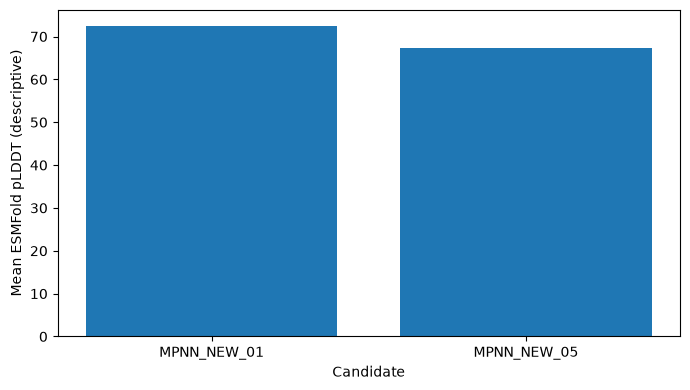

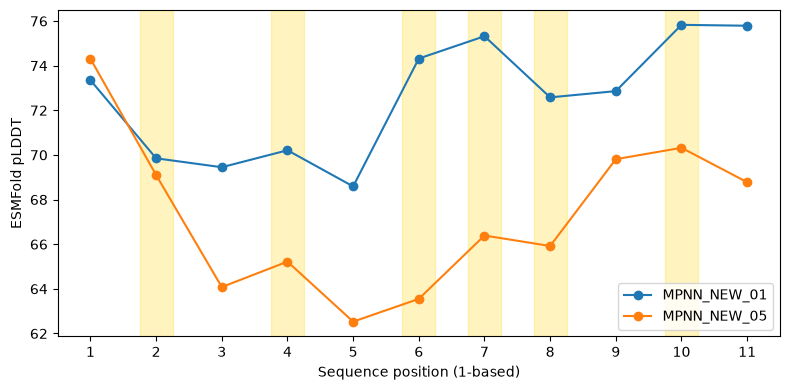

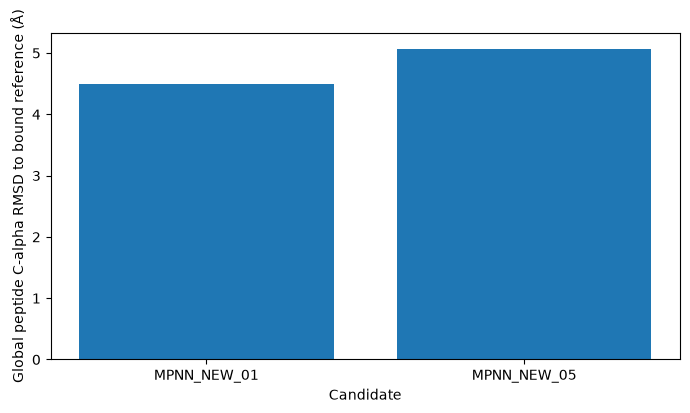

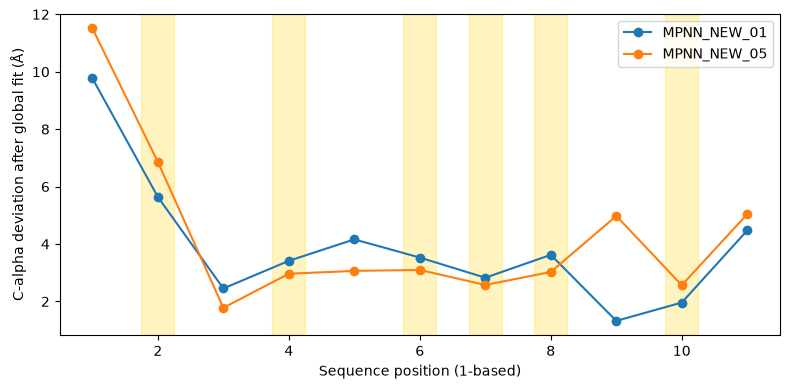

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(result_df["candidate_id"], result_df["mean_pLDDT"])
ax.set_ylabel("Mean ESMFold pLDDT (descriptive)")
ax.set_xlabel("Candidate")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "08g_mean_plddt.png", dpi=220)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
for cid, group in per_residue_df.groupby("candidate_id", sort=False):
    ax.plot(group["sequence_position"], group["pLDDT"], marker="o", label=cid)
for position in PROTECTED_POSITIONS_1BASED:
    ax.axvspan(position - 0.25, position + 0.25, color="gold", alpha=0.25)
ax.set_xlabel("Sequence position (1-based)")
ax.set_ylabel("ESMFold pLDDT")
ax.set_xticks(range(1, int(per_residue_df["sequence_position"].max()) + 1))
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "08g_per_residue_plddt.png", dpi=220)
plt.show()

if reference_available:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(result_df["candidate_id"], result_df["global_CA_RMSD_A"])
    ax.set_ylabel("Global peptide C-alpha RMSD to bound reference (Å)")
    ax.set_xlabel("Candidate")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "08g_global_CA_RMSD_to_bound.png", dpi=220)
    plt.show()

if not deviation_df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    for cid, group in deviation_df.groupby("candidate_id", sort=False):
        ax.plot(group["sequence_position"], group["CA_distance_after_global_fit_A"], marker="o", label=cid)
    for position in PROTECTED_POSITIONS_1BASED:
        ax.axvspan(position - 0.25, position + 0.25, color="gold", alpha=0.25)
    ax.set_xlabel("Sequence position (1-based)")
    ax.set_ylabel("C-alpha deviation after global fit (Å)")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "08g_per_residue_CA_deviation.png", dpi=220)
    plt.show()


## 10. Quality control and run report

Core prediction QC and bound-reference QC are reported separately. A pLDDT-only execution may pass core QC, but it is never labelled as a completed bound-reference validation.


In [10]:
core_checks = [
    {"check": "candidate_sequences_traced_from_08f", "pass": bool(TARGET_CANDIDATES), "scope": "core"},
    {"check": "all_prediction_pdbs_present", "pass": bool(result_df["pdb_path"].map(lambda p: Path(p).exists()).all()), "scope": "core"},
    {"check": "all_prediction_sequences_match", "pass": bool(result_df["sequence_matches_expected"].all()), "scope": "core"},
    {"check": "all_plddt_values_valid", "pass": bool(result_df["pLDDT_valid"].all()), "scope": "core"},
]
reference_checks = [
    {"check": "reference_file_configured_and_present", "pass": bool(reference_available and REFERENCE_PDB.exists()), "scope": "bound_reference"},
    {"check": "reference_comparison_completed", "pass": bool(reference_available and result_df["reference_comparison_status"].eq("completed").all()), "scope": "bound_reference"},
    {"check": "complete_reference_mapping", "pass": bool(reference_available and result_df["reference_mapping_coverage"].eq(1.0).all()), "scope": "bound_reference"},
]
if PROTECTED_POSITIONS_1BASED:
    reference_checks.append({
        "check": "protected_position_comparison_completed",
        "pass": bool(reference_available and result_df["protected_comparison_status"].str.startswith("completed").all()),
        "scope": "bound_reference",
    })

qc = pd.DataFrame(core_checks + reference_checks)
qc.to_csv(TABLE_DIR / "08g_QC.csv", index=False)
core_qc_passed = bool(qc.loc[qc["scope"] == "core", "pass"].all())
bound_reference_qc_passed = bool(qc.loc[qc["scope"] == "bound_reference", "pass"].all())
display(qc)
print("CORE_QC_PASSED:", core_qc_passed)
print("BOUND_REFERENCE_QC_PASSED:", bound_reference_qc_passed)

report_lines = [
    "# 08g ESMFold structural validation run report",
    "",
    f"- Prediction mode: `{PREDICTION_MODE}`",
    f"- Candidates: {len(result_df)}",
    f"- Core QC passed: **{core_qc_passed}**",
    f"- Bound reference configured: **{reference_available}**",
    f"- Bound-reference QC passed: **{bound_reference_qc_passed}**",
    f"- Protected positions (1-based): `{PROTECTED_POSITIONS_1BASED}`",
    "",
    "ESMFold is used as a structural plausibility check only. Short-peptide pLDDT and RMSD are descriptive comparative signals, not affinity measurements.",
]
if not reference_available:
    report_lines.extend([
        "",
        "**Bound-reference validation was not performed because REFERENCE_PDB was not configured.**",
    ])
(OUTPUT_ROOT / "08g_structural_validation_report.md").write_text("\n".join(report_lines) + "\n")

if not core_qc_passed:
    raise RuntimeError("Core ESMFold QC failed; inspect 08g_QC.csv.")


,check,pass,scope
0,candidate_sequences_traced_from_08f,True,core
1,all_prediction_pdbs_present,True,core
2,all_prediction_sequences_match,True,core
3,all_plddt_values_valid,True,core
4,reference_file_configured_and_present,True,bound_reference
5,reference_comparison_completed,True,bound_reference
6,complete_reference_mapping,True,bound_reference
7,protected_position_comparison_completed,True,bound_reference


CORE_QC_PASSED: True
BOUND_REFERENCE_QC_PASSED: True
